# Konkan Canara - Neural Network + U-Net Hybrid Model for Total Precipitation Prediction (8-Step Input Sequence)

In [1]:
# Importing the required libraries
import numpy as np
import joblib
import importlib
    
import random
import gc

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary

import KC_Data_Preprocessing as KCD
import Baseline_Model_Definitions as BMD
import Baseline_Model_Utils as BMU
import UNet_Model_Definitions as UMD
import UNet_Model_Utils as UMU

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
torch.cuda.get_device_properties()

_CudaDeviceProperties(name='NVIDIA GeForce RTX 4060 Laptop GPU', major=8, minor=9, total_memory=8187MB, multi_processor_count=24, uuid=a73fa0eb-512f-ffe4-cf94-f2e7b26c980c, pci_bus_id=1, pci_device_id=0, pci_domain_id=0, L2_cache_size=32MB)

In [5]:
start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

In [6]:
torch.cuda.init()

In [7]:
gc.collect()
torch.cuda.empty_cache()

## Data Loading and Preprocessing

In [8]:
importlib.reload(KCD);

In [9]:
feature_scaler = joblib.load('feature_scaler_tp.pkl')
target_scaler = joblib.load('target_scaler_tp.pkl')

SEQ_LEN = 8

data = KCD.prepare_konkan_data(
    file_path='KC_6H_2001-2025_Final.csv', 
    feature_scaler=feature_scaler, 
    target_scaler=target_scaler, 
    seq_len=SEQ_LEN, 
    target_variable='tp'
)

X_train, y_train = data['train']
X_val, y_val = data['val']

height = data['meta']['height']
width = data['meta']['width']
num_channels = data['meta']['channels'] 
feature_names = data['meta']['feature_names']

print(f'X_train shape: {X_train.shape} (2001-2018)')
print(f'X_val shape: {X_val.shape} (2019-2020)')

X_train shape: (26288, 8, 32, 12, 8) (2001-2018)
X_val shape: (2924, 8, 32, 12, 8) (2019-2020)


In [10]:
feature_names

['msl', 'sst', 'u10', 'v10', 'ws', 't2m', 'rh', 'tp']

In [11]:
height, width, num_channels

(32, 12, 8)

### Reshaping the data and preparing DataLoaders

In [12]:
# Reshape X_train from (26292, SEQ_LEN, 32, 12, 8) to (26292, SEQ_LEN * 32 * 12 * 8)
X_train_flat = X_train.reshape(X_train.shape[0], -1) 

# Reshape y_train from (26292, 32, 12, 1) to (26292, 32 * 12 * 1)
y_train_flat = y_train.reshape(y_train.shape[0], -1)

X_val_flat = X_val.reshape(X_val.shape[0], -1)
y_val_flat = y_val.reshape(y_val.shape[0], -1)

print(f'--- Flattened Shapes for Neural Network ---')
print(f'Train: X={X_train_flat.shape}, y={y_train_flat.shape}')
print(f'Val: X={X_val_flat.shape}, y={y_val_flat.shape}')

--- Flattened Shapes for Neural Network ---
Train: X=(26288, 24576), y=(26288, 384)
Val: X=(2924, 24576), y=(2924, 384)


In [13]:
nn_dataset_train = TensorDataset(torch.from_numpy(X_train_flat).float().to(device), 
                                 torch.from_numpy(y_train_flat).float().to(device))
nn_dataset_val = TensorDataset(torch.from_numpy(X_val_flat).float().to(device), 
                               torch.from_numpy(y_val_flat).float().to(device))

BATCH_SIZE_NN = 128

nn_train_loader = DataLoader(nn_dataset_train, batch_size=BATCH_SIZE_NN, shuffle=True, pin_memory=False)
nn_val_loader = DataLoader(nn_dataset_val, batch_size=BATCH_SIZE_NN, shuffle=False, pin_memory=False)

## PyTorch Neural Network Baseline

In [14]:
importlib.reload(BMD);
importlib.reload(BMU);

In [15]:
INPUT_SIZE_NN = X_train_flat.shape[1]
HIDDEN_UNITS_NN = [32]
OUTPUT_SIZE_NN = height * width

nn_model = BMD.NeuralNet(
    input_size=INPUT_SIZE_NN, 
    hidden_sizes=HIDDEN_UNITS_NN, 
    output_size=OUTPUT_SIZE_NN
).to(device)

In [16]:
summary(nn_model, input_size=(BATCH_SIZE_NN, INPUT_SIZE_NN))

Layer (type:depth-idx)                   Output Shape              Param #
NeuralNet                                [128, 384]                --
├─Sequential: 1-1                        [128, 384]                --
│    └─Linear: 2-1                       [128, 32]                 786,464
│    └─ReLU: 2-2                         [128, 32]                 --
│    └─Linear: 2-3                       [128, 384]                12,672
Total params: 799,136
Trainable params: 799,136
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 102.29
Input size (MB): 12.58
Forward/backward pass size (MB): 0.43
Params size (MB): 3.20
Estimated Total Size (MB): 16.21

In [17]:
nn_loss_fn = nn.MSELoss()
nn_optimizer = BMU.nn_optimizer(nn_model)
NN_EPOCHS = 50

In [18]:
torch.cuda.synchronize()
start_event.record()

train_losses_nn, val_losses_nn = BMU.nn_train_model(
    nn_model, 
    nn_train_loader, 
    nn_val_loader, 
    nn_optimizer,      
    nn_loss_fn,      
    epochs=NN_EPOCHS,
)

end_event.record()
torch.cuda.synchronize()

Epoch 1/50 | Train Loss: 0.057803 | Val Loss: 0.023898
  --> Saved Best Weights


Epoch 2/50 | Train Loss: 0.017236 | Val Loss: 0.020618
  --> Saved Best Weights


Epoch 3/50 | Train Loss: 0.015964 | Val Loss: 0.020049
  --> Saved Best Weights


Epoch 4/50 | Train Loss: 0.015831 | Val Loss: 0.019976
  --> Saved Best Weights


Epoch 5/50 | Train Loss: 0.015812 | Val Loss: 0.019963
  --> Saved Best Weights


...

Epoch 46/50 | Train Loss: 0.015800 | Val Loss: 0.020056


Epoch 47/50 | Train Loss: 0.015812 | Val Loss: 0.019903


Epoch 48/50 | Train Loss: 0.015798 | Val Loss: 0.019936


Epoch 49/50 | Train Loss: 0.015805 | Val Loss: 0.019945


Epoch 50/50 | Train Loss: 0.015828 | Val Loss: 0.019973


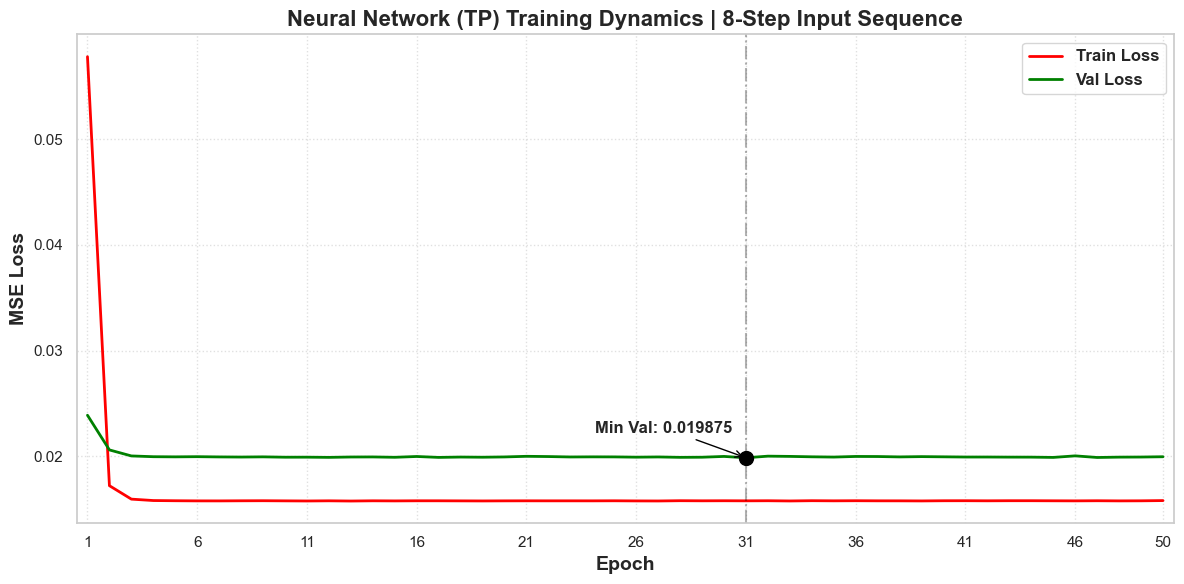

In [19]:
BMU.plot_training_dynamics(
    train_losses_nn, val_losses_nn, loss_name='MSE Loss', model_name='Neural Network (TP)', seq_len=SEQ_LEN
)

In [20]:
elapsed_time_nn = start_event.elapsed_time(end_event)
nn_duration = elapsed_time_nn / 1000

minutes, seconds = divmod(nn_duration, 60)

if minutes > 0:
    print(f'Neural Network Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Neural Network Training Time: {seconds:.2f} seconds')

Neural Network Training Time: 31.48 seconds


In [21]:
torch.save(nn_model.state_dict(), 'NeuralNet_8S_TP.pth');

### Generating hints and data loaders for the U-Net models

In [22]:
nn_model.eval()

with torch.inference_mode():
    X_train_flat_tensor = torch.as_tensor(X_train_flat, device=device, dtype=torch.float32)
    X_val_flat_tensor = torch.as_tensor(X_val_flat, device=device, dtype=torch.float32)

    nn_hint_train_flat = nn_model(X_train_flat_tensor)
    nn_hint_val_flat = nn_model(X_val_flat_tensor)

nn_hint_train_tensor = nn_hint_train_flat.view(-1, 1, height, width)
nn_hint_val_tensor = nn_hint_val_flat.view(-1, 1, height, width)

X_train_last = torch.from_numpy(X_train[:, -1, :, :, :]).float().to(device).permute(0, 3, 1, 2)
X_val_last = torch.from_numpy(X_val[:, -1, :, :, :]).float().to(device).permute(0, 3, 1, 2)

# Concatenating Features + Hint Channel (N, 8+1, 32, 12)
hybrid_X_train_tensor = torch.cat([X_train_last, nn_hint_train_tensor], dim=1)
hybrid_X_val_tensor = torch.cat([X_val_last, nn_hint_val_tensor], dim=1)

y_train_tensor = torch.from_numpy(y_train).float().to(device).permute(0, 3, 1, 2)
y_val_tensor = torch.from_numpy(y_val).float().to(device).permute(0, 3, 1, 2)

print(f'Hybrid Input Shapes: Train={hybrid_X_train_tensor.shape}, Val={hybrid_X_val_tensor.shape}')

Hybrid Input Shapes: Train=torch.Size([26288, 9, 32, 12]), Val=torch.Size([2924, 9, 32, 12])


In [23]:
BATCH_SIZE_UNET = 128

unet_train_loader = DataLoader(
    TensorDataset(hybrid_X_train_tensor, y_train_tensor), 
    batch_size=BATCH_SIZE_UNET, 
    shuffle=True,    
    pin_memory=False
)

unet_val_loader = DataLoader(
    TensorDataset(hybrid_X_val_tensor, y_val_tensor), 
    batch_size=BATCH_SIZE_UNET, 
    shuffle=False,
    pin_memory=False
)

## U-Net Models

In [24]:
importlib.reload(UMU);
importlib.reload(UMD);

In [ ]:
INPUT_CHANNELS_UNET = num_channels + 1
OUTPUT_CHANNELS_UNET = 2
UNET_EPOCHS = 50

In [26]:
unet_loss_fn = torch.nn.GaussianNLLLoss(eps=1e-6, full=True, reduction='none')

### Standard U-Net

In [27]:
hybrid_model1 = UMD.Standard_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model1)

In [28]:
summary(hybrid_model1, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width)) 

Layer (type:depth-idx)                        Output Shape              Param #
Standard_UNet                                 [128, 2, 32, 12]          --
├─BaseDoubleConv: 1-1                         [128, 64, 32, 12]         --
│    └─Sequential: 2-1                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                       [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                         [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                       [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-6                         [128, 64, 32, 12]         --
├─BaseDown: 1-2                               [128, 128, 16, 6]         --
│    └─Sequential: 2-2                        [128, 128, 16, 6]         --
│    │    └─LPPool2d: 3-7                     [128, 64, 16, 6]          --
│    │    └

In [29]:
gc.collect()
torch.cuda.empty_cache()

In [30]:
torch.cuda.synchronize()
start_event.record()

train_losses1, val_losses1, lr_history1 = UMU.train_model(
    hybrid_model1, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device,
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: -0.316503 | Val Loss: -0.561488 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -0.769276 | Val Loss: -0.914666 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -1.131643 | Val Loss: -1.223147 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -1.395250 | Val Loss: -1.375563 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -1.598497 | Val Loss: -1.598967 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -3.292787 | Val Loss: -2.567128 | LR: 1.00e-08


Epoch 47 | Train Loss: -3.293691 | Val Loss: -2.567314 | LR: 1.00e-08


Epoch 48 | Train Loss: -3.292577 | Val Loss: -2.567138 | LR: 1.00e-08


Epoch 49 | Train Loss: -3.292003 | Val Loss: -2.567381 | LR: 1.00e-08


Epoch 50 | Train Loss: -3.294182 | Val Loss: -2.567340 | LR: 1.00e-08


In [31]:
elapsed_time_unet1 = start_event.elapsed_time(end_event)
unet_duration1 = elapsed_time_unet1 / 1000

minutes, seconds = divmod(unet_duration1, 60)

if minutes > 0:
    print(f'Standard U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Standard U-Net Training Time: {seconds:.2f} seconds')

Standard U-Net Training Time: 5 minutes and 58.62 seconds


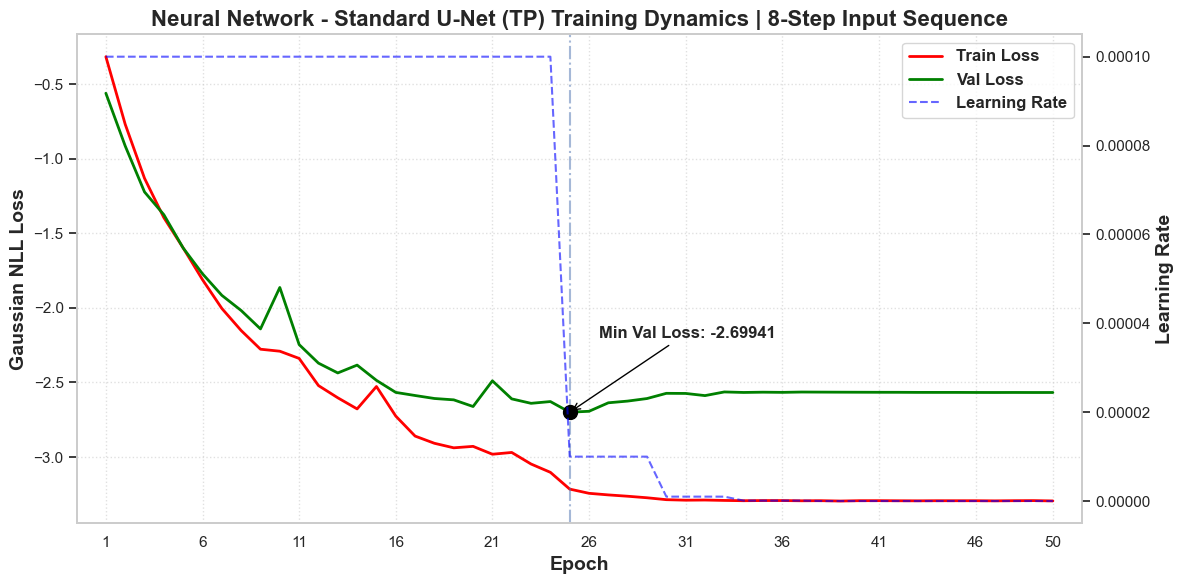

In [32]:
UMU.plot_training_dynamics(train_losses1, val_losses1, lr_history1, 
                       'Neural Network - Standard U-Net (TP)', SEQ_LEN)

In [33]:
torch.save(hybrid_model1.state_dict(), 'NeuralNet_Standard_U-Net_Hybrid_TP_8S.pth')

In [34]:
del hybrid_model1, 
del optimizer
del scheduler

In [35]:
gc.collect()
torch.cuda.empty_cache()

### Residual U-Net

In [36]:
hybrid_model2 = UMD.Residual_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model2)

In [37]:
summary(hybrid_model2, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width))

Layer (type:depth-idx)                        Output Shape              Param #
Residual_UNet                                 [128, 2, 32, 12]          --
├─ResidualDoubleConv: 1-1                     [128, 64, 32, 12]         --
│    └─Sequential: 2-1                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                       [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                         [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                       [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                    [128, 64, 32, 12]         128
│    └─Sequential: 2-2                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-6                       [128, 64, 32, 12]         576
│    │    └─GroupNorm: 3-7                    [128, 64, 32, 12]         128
│    └─ReLU: 2-3                              [128, 64, 32, 12]         --
├─BaseDow

In [38]:
gc.collect()
torch.cuda.empty_cache()

In [39]:
torch.cuda.synchronize()
start_event.record()

train_losses2, val_losses2, lr_history2 = UMU.train_model(
    hybrid_model2, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device, 
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: -0.714765 | Val Loss: -1.191381 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -1.430902 | Val Loss: -1.477981 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -1.750026 | Val Loss: -1.790100 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -2.025729 | Val Loss: -1.977104 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -2.171419 | Val Loss: -2.105009 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -3.316705 | Val Loss: -1.978486 | LR: 1.00e-08


Epoch 47 | Train Loss: -3.316770 | Val Loss: -1.978316 | LR: 1.00e-08


Epoch 48 | Train Loss: -3.316639 | Val Loss: -1.978230 | LR: 1.00e-08


Epoch 49 | Train Loss: -3.315893 | Val Loss: -1.977789 | LR: 1.00e-08


Epoch 50 | Train Loss: -3.316889 | Val Loss: -1.977617 | LR: 1.00e-08


In [40]:
elapsed_time_unet2 = start_event.elapsed_time(end_event)
unet_duration2 = elapsed_time_unet2 / 1000

minutes, seconds = divmod(unet_duration2, 60)

if minutes > 0:
    print(f'Residual U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Residual U-Net Training Time: {seconds:.2f} seconds')

Residual U-Net Training Time: 7 minutes and 51.49 seconds


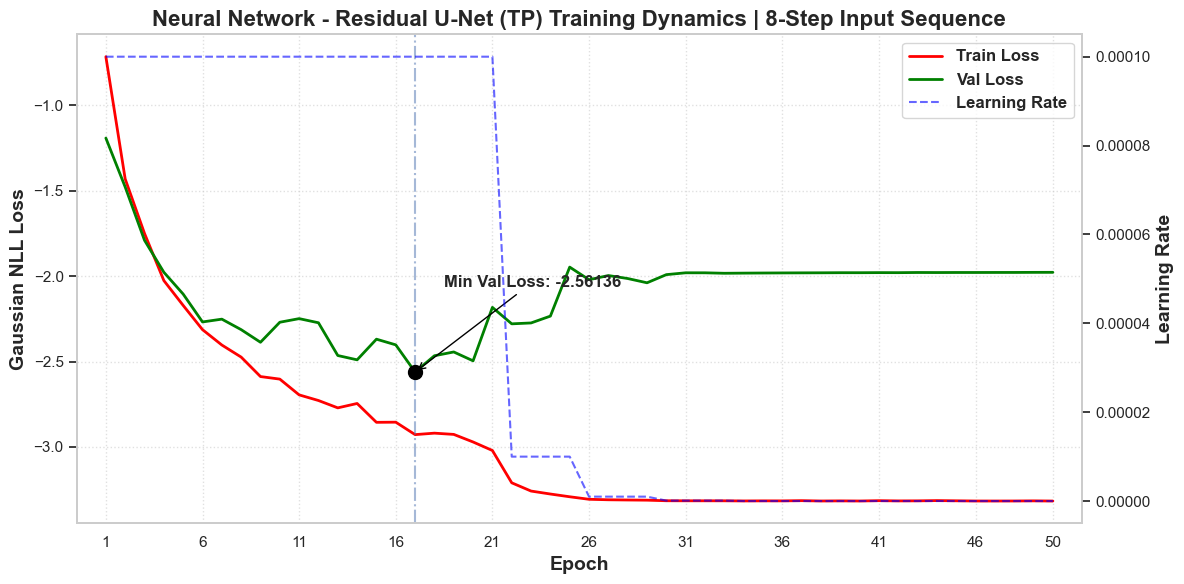

In [41]:
UMU.plot_training_dynamics(train_losses2, val_losses2, lr_history2, 
                       'Neural Network - Residual U-Net (TP)', SEQ_LEN)

In [42]:
torch.save(hybrid_model2.state_dict(), 'NeuralNet_Residual_U-Net_Hybrid_TP_8S.pth')

In [43]:
del hybrid_model2, 
del optimizer
del scheduler

In [44]:
gc.collect()
torch.cuda.empty_cache()

### Attention U-Net

In [45]:
hybrid_model3 = UMD.Attention_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model3)

In [46]:
summary(hybrid_model3, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width))

Layer (type:depth-idx)                        Output Shape              Param #
Attention_UNet                                [128, 2, 32, 12]          --
├─BaseDoubleConv: 1-1                         [128, 64, 32, 12]         --
│    └─Sequential: 2-1                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                       [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                         [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                       [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-6                         [128, 64, 32, 12]         --
├─BaseDown: 1-2                               [128, 128, 16, 6]         --
│    └─Sequential: 2-2                        [128, 128, 16, 6]         --
│    │    └─LPPool2d: 3-7                     [128, 64, 16, 6]          --
│    │    └

In [47]:
gc.collect()
torch.cuda.empty_cache()

In [48]:
torch.cuda.synchronize()
start_event.record()

train_losses3, val_losses3, lr_history3 = UMU.train_model(
    hybrid_model3, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device,
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: -0.096407 | Val Loss: -0.341727 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -0.538632 | Val Loss: -0.710898 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -0.912430 | Val Loss: -1.049023 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -1.236083 | Val Loss: -1.296301 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -1.462617 | Val Loss: -1.434813 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -3.233007 | Val Loss: -2.546006 | LR: 1.00e-08


Epoch 47 | Train Loss: -3.231766 | Val Loss: -2.546139 | LR: 1.00e-08


Epoch 48 | Train Loss: -3.231902 | Val Loss: -2.545963 | LR: 1.00e-08


Epoch 49 | Train Loss: -3.232032 | Val Loss: -2.545562 | LR: 1.00e-08


Epoch 50 | Train Loss: -3.233207 | Val Loss: -2.545936 | LR: 1.00e-08


In [49]:
elapsed_time_unet3 = start_event.elapsed_time(end_event)
unet_duration3 = elapsed_time_unet3 / 1000

minutes, seconds = divmod(unet_duration3, 60)

if minutes > 0:
    print(f'Attention U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Attention U-Net Training Time: {seconds:.2f} seconds')

Attention U-Net Training Time: 8 minutes and 37.03 seconds


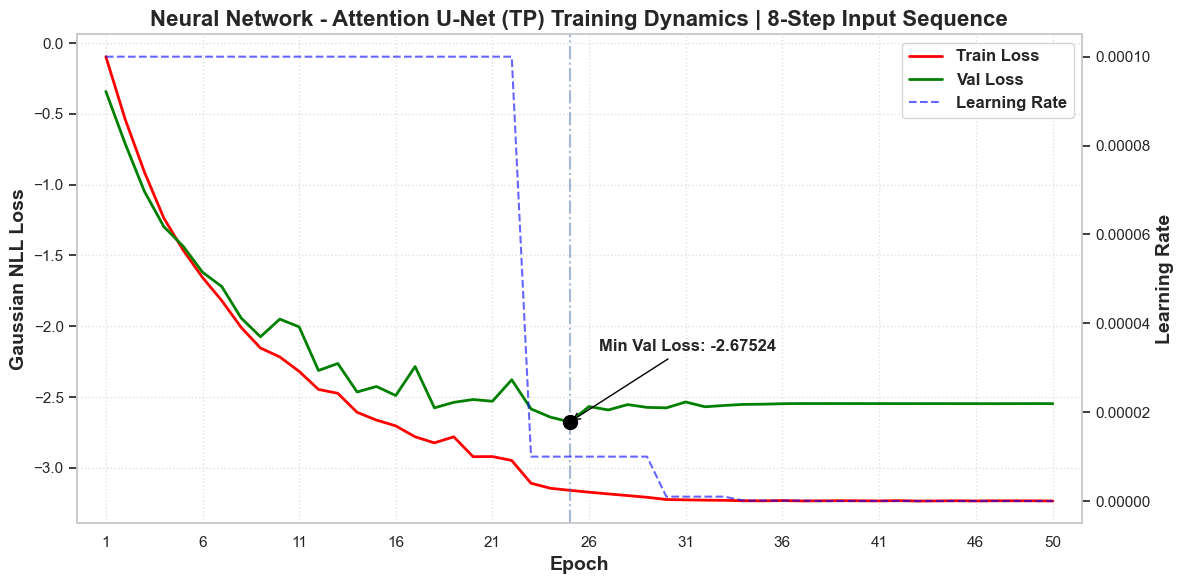

In [50]:
UMU.plot_training_dynamics(train_losses3, val_losses3, lr_history3, 
                       'Neural Network - Attention U-Net (TP)', SEQ_LEN)

In [51]:
torch.save(hybrid_model3.state_dict(), 'NeuralNet_Attention_U-Net_Hybrid_TP_8S.pth')

In [52]:
del hybrid_model3
del optimizer
del scheduler

In [53]:
gc.collect()
torch.cuda.empty_cache()

### CBAM (Convolution Block Attention Module) U-Net

In [54]:
hybrid_model4 = UMD.CBAM_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model4)

In [55]:
summary(hybrid_model4, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width))

Layer (type:depth-idx)                             Output Shape              Param #
CBAM_UNet                                          [128, 2, 32, 12]          --
├─CBAMDoubleConv: 1-1                              [128, 64, 32, 12]         --
│    └─Sequential: 2-1                             [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                            [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                         [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                              [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                            [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                         [128, 64, 32, 12]         128
│    │    └─ReLU: 3-6                              [128, 64, 32, 12]         --
│    └─ChannelAttention: 2-2                       [128, 64, 1, 1]           --
│    │    └─AdaptiveAvgPool2d: 3-7                 [128, 64, 1, 1]           --
│    │    └─Sequential: 3-

In [56]:
gc.collect()
torch.cuda.empty_cache()

In [57]:
torch.cuda.synchronize()
start_event.record()

train_losses4, val_losses4, lr_history4 = UMU.train_model(
    hybrid_model4, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: -0.012531 | Val Loss: -0.255765 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -0.459678 | Val Loss: -0.640050 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -0.847888 | Val Loss: -1.003314 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -1.193781 | Val Loss: -1.238524 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -1.434037 | Val Loss: -1.372570 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -3.287681 | Val Loss: -2.468216 | LR: 1.00e-08


Epoch 47 | Train Loss: -3.288865 | Val Loss: -2.468230 | LR: 1.00e-08


Epoch 48 | Train Loss: -3.286189 | Val Loss: -2.468071 | LR: 1.00e-08


Epoch 49 | Train Loss: -3.288860 | Val Loss: -2.468261 | LR: 1.00e-08


Epoch 50 | Train Loss: -3.289296 | Val Loss: -2.468003 | LR: 1.00e-08


In [58]:
elapsed_time_unet4 = start_event.elapsed_time(end_event)
unet_duration4 = elapsed_time_unet4 / 1000

minutes, seconds = divmod(unet_duration4, 60)

if minutes > 0:
    print(f'CBAM U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'CBAM U-Net Training Time: {seconds:.2f} seconds')

CBAM U-Net Training Time: 8 minutes and 29.82 seconds


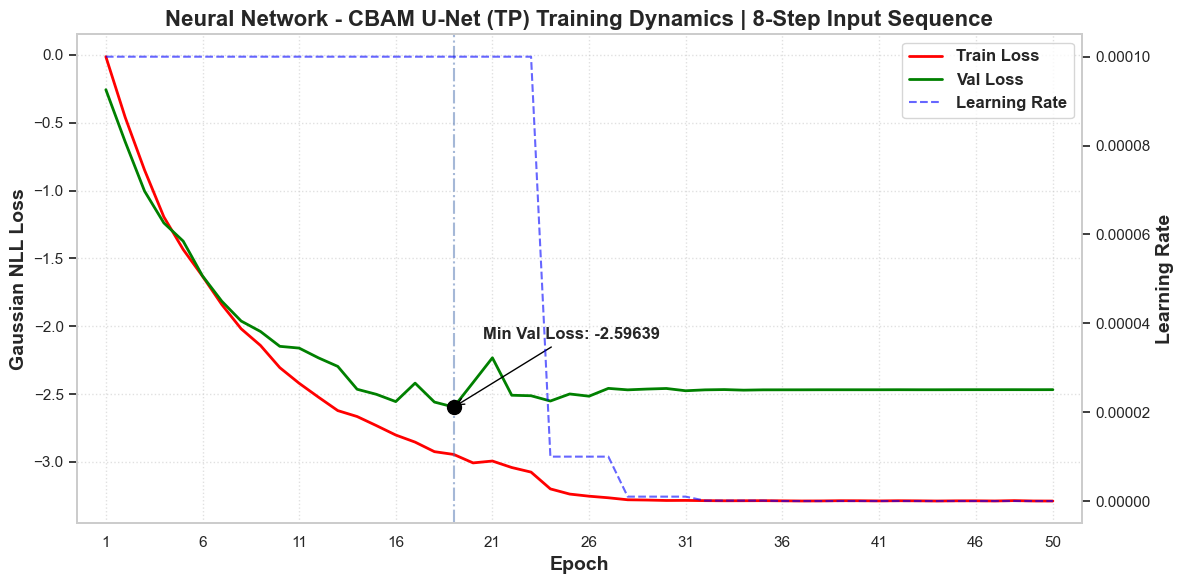

In [59]:
UMU.plot_training_dynamics(train_losses4, val_losses4, lr_history4, 
                       'Neural Network - CBAM U-Net (TP)', SEQ_LEN)

In [60]:
torch.save(hybrid_model4.state_dict(), 'NeuralNet_CBAM_U-Net_Hybrid_TP_8S.pth')

In [61]:
del hybrid_model4 
del optimizer
del scheduler

In [62]:
gc.collect()
torch.cuda.empty_cache()

## Total Training Time for Each Hybrid Model

In [63]:
total_duration1 = nn_duration + unet_duration1
minutes, seconds = divmod(total_duration1, 60)

if minutes > 0:
    print(f'Total Training Time for Neural Network - Standard U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for Neural Network - Standard U-Net: {seconds:.2f} seconds')

Total Training Time for Neural Network - Standard U-Net: 6 minutes and 30.10 seconds


In [64]:
total_duration2 = nn_duration + unet_duration2
minutes, seconds = divmod(total_duration2, 60)

if minutes > 0:
    print(f'Total Training Time for Neural Network - Residual U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for Neural Network - Residual U-Net: {seconds:.2f} seconds')

Total Training Time for Neural Network - Residual U-Net: 8 minutes and 22.97 seconds


In [65]:
total_duration3 = nn_duration + unet_duration3
minutes, seconds = divmod(total_duration3, 60)

if minutes > 0:
    print(f'Total Training Time for Neural Network - Attention U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for Neural Network - Attention U-Net: {seconds:.2f} seconds')

Total Training Time for Neural Network - Attention U-Net: 9 minutes and 8.50 seconds


In [66]:
total_duration4 = nn_duration + unet_duration4
minutes, seconds = divmod(total_duration4, 60)

if minutes > 0:
    print(f'Total Training Time for Neural Network - CBAM U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for Neural Network - CBAM U-Net: {seconds:.2f} seconds')

Total Training Time for Neural Network - CBAM U-Net: 9 minutes and 1.29 seconds


***